# SAE Training on Federated Learning Checkpoints

In [8]:
# # Install overcomplete if not already installed
# !pip install -q einops opencv-python scikit-image
# !pip install -q overcomplete

In [13]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
sys.path.append('..')

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

class SimpleCNN(nn.Module):
    def __init__(self, conv_channels: List[int] = None, num_classes: int = 10, input_channels: int = 1):
        super(SimpleCNN, self).__init__()
        if conv_channels is None:
            conv_channels = [32, 64, 128]
        
        self.conv1 = nn.Conv2d(input_channels, conv_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(conv_channels[0], conv_channels[1], 3, padding=1)
        self.conv3 = nn.Conv2d(conv_channels[1], conv_channels[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.spatial_dim = 3 if input_channels == 1 else 4
        self.fc = nn.Linear(conv_channels[2] * self.spatial_dim * self.spatial_dim, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    return SimpleCNN(
        conv_channels=config.conv_channels,
        num_classes=config.num_classes,
        input_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)
            x = model.pool(torch.relu(model.conv1(x)))
            x = model.pool(torch.relu(model.conv2(x)))
            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())
    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)
    print("Activation shape:", activations.shape)
    print("Label shape:", labels.shape)
    return activations, labels

In [14]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)
    
    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)
    
    desired_sparsity = 0.10
    
    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss
        
    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=20, device=config.device)
    
    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [15]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('../default_config.json')

# Load IID model
model_iid = load_model_from_checkpoint(config_iid, '../checkpoints/iid_5class/checkpoints/checkpoint_round_5.pt')

# Extract activations from 2nd layer
activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
print(f"IID Activations shape: {activations_iid.shape}")

# Train JumpReLU SAE
sae_iid = train_jump_sae(activations_iid, "IID", config_iid)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 3.44MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 117kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]
C:\Users\Fatim_Sproj\AppData\Local\Temp\ipykernel_29612\2450741153.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_di

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/20], Loss: 761.8498, R2: 0.5103, L0: 75.9050, Dead Features: 3.1%, Time: 0.0988 seconds
Epoch[2/20], Loss: 745.3037, R2: 0.9171, L0: 62.5236, Dead Features: 39.8%, Time: 0.0981 seconds
Epoch[3/20], Loss: 729.6801, R2: 0.9528, L0: 60.5442, Dead Features: 44.5%, Time: 0.1029 seconds
Epoch[4/20], Loss: 714.1550, R2: 0.9669, L0: 62.1052, Dead Features: 46.9%, Time: 0.0810 seconds
Epoch[5/20], Loss: 698.6790, R2: 0.9739, L0: 62.3340, Dead Features: 46.9%, Time: 0.1022 seconds
Epoch[6/20], Loss: 683.2304, R2: 0.9780, L0: 62.7480, Dead Features: 46.9%, Time: 0.0990 seconds
Epoch[7/20], Loss: 667.7983, R2: 0.9811, L0: 62.6821, Dead Features: 47.3%, Time: 0.0844 seconds
Epoch[8/20], Loss: 652.3775, R2: 0

## Non-IID Experiment

In [16]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('../configs/non_iid_dirichlet.json')

# Load Non-IID model
model_niid = load_model_from_checkpoint(config_niid, '../checkpoints/non_iid_dirichlet/checkpoints/checkpoint_round_5.pt')

# Extract activations from 2nd layer
activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
print(f"Non-IID Activations shape: {activations_niid.shape}")

# Train JumpReLU SAE
sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)

C:\Users\Fatim_Sproj\AppData\Local\Temp\ipykernel_29612\2450741153.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=config.dev

Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
Non-IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for Non-IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/20], Loss: 761.8514, R2: 0.6188, L0: 91.1658, Dead Features: 2.3%, Time: 0.0963 seconds
Epoch[2/20], Loss: 745.2462, R2: 0.9281, L0: 73.5772, Dead Features: 32.8%, Time: 0.0986 seconds
Epoch[3/20], Loss: 729.5529, R2: 0.9573, L0: 71.7369, Dead Features: 37.1%, Time: 0.0960 seconds
Epoch[4/20], Loss: 713.9752, R2: 0.9696, L0: 72.9356, Dead Features: 37.5%, Time: 0.0888 seconds
Epoch[5/20], Loss: 698.4588, R2: 0.9760, L0: 73.1153, Dead Features: 37.5%, Time: 0.0833 seconds
Epoch[6/20], Loss: 682.9784, R2: 0.9800, L0: 73.0239, Dead Features: 37.5%, Time: 0.1100 seconds
Epoch[7/20], Loss: 667.5207, R2: 0.9828, L0: 72.7673, Dead Features: 38.3%, Time: 0.0917 seconds
Epoch[8/20], Loss: 652.0788, R2: 0.9848, L0: 72.6589, Dead Features: 38.3%, Time: 0.0816 seconds
Epoc


SAE GEOMETRY ANALYSIS START

IID activation shape: torch.Size([251811, 64])
Non-IID activation shape: torch.Size([251811, 64])

[1] Extracting dictionary feature directions
IID dictionary: torch.Size([256, 64])
Non-IID dictionary: torch.Size([256, 64])

[2] Cross-model feature similarity
Mean max similarity: 0.34635409712791443
Median max similarity: 0.33879968523979187


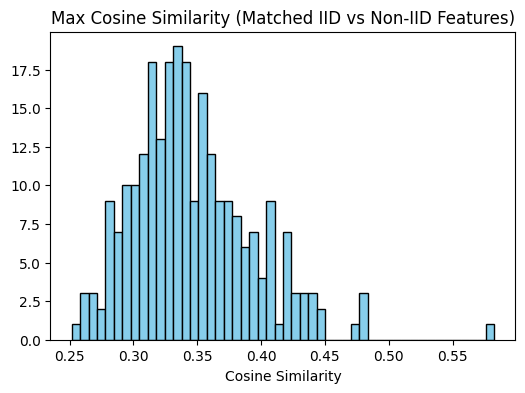


[3] Internal feature geometry
IID mean pairwise similarity: 0.0031704754
Non-IID mean pairwise similarity: 0.0030620468


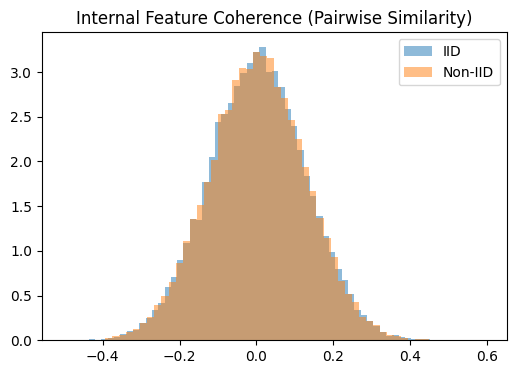


[4] PCA geometry


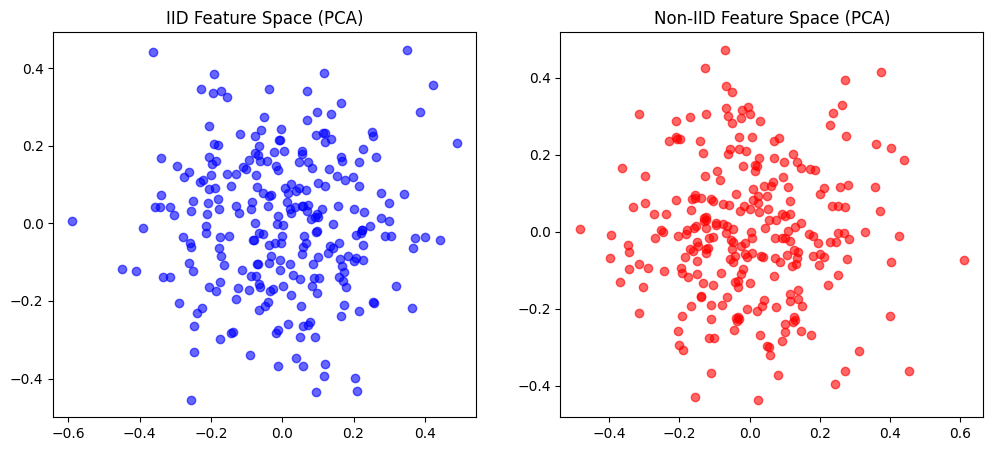


[5] Computing SAE feature activations
IID active feature fraction: 0.2778361737728119
Non-IID active feature fraction: 0.3284977376461029

[6] Feature entropy
IID Normalized Feature Entropy: 0.8079
Non-IID Normalized Feature Entropy: 0.8327
(High entropy = model uses features uniformly; Low = model relies on very few features)

[7] Per-Class Projection: Non-IID activations onto IID features
Class 0 | Mean Projection: 0.5988 | Strongest IID Feature: 89 (val: 6.3709)
Class 1 | Mean Projection: 0.3084 | Strongest IID Feature: 89 (val: 3.0639)
Class 2 | Mean Projection: 0.5487 | Strongest IID Feature: 89 (val: 5.7757)
Class 3 | Mean Projection: 0.5448 | Strongest IID Feature: 89 (val: 5.8205)
Class 4 | Mean Projection: 0.4588 | Strongest IID Feature: 89 (val: 4.7171)

[8] Feature similarity heatmaps


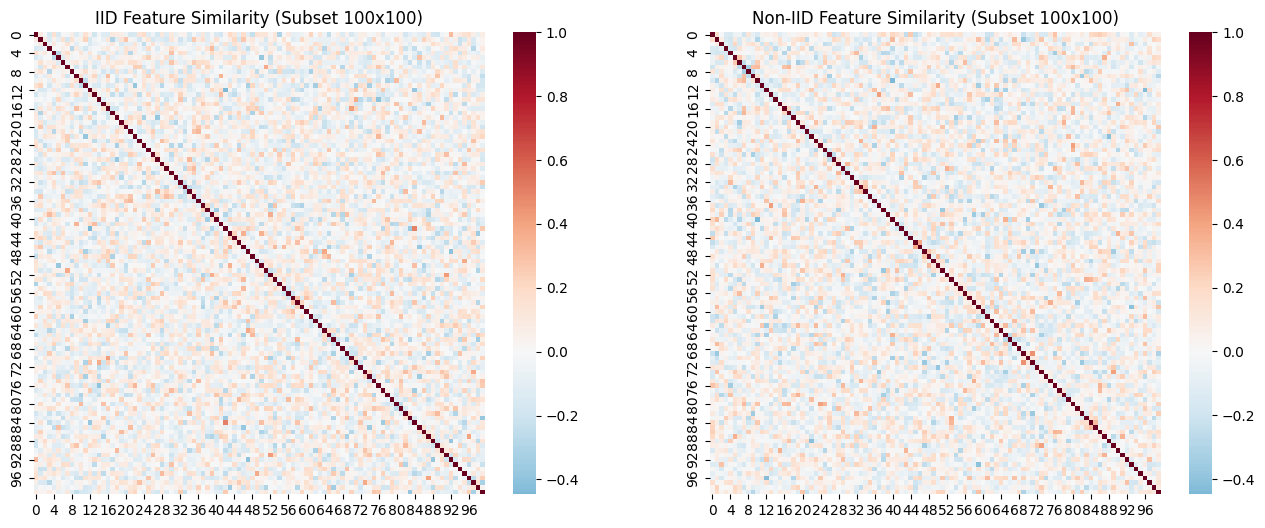


ANALYSIS COMPLETE


In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0) 
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue
    
    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)
    
    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")